In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

IMPORTING THE DATA

In [2]:
customer_info = pd.read_csv('customer_info.csv', index_col = False)

In [194]:
customer_info

,Unnamed: 0,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,0,29930,April Clark,female,01/15/1972 02:27 PM,2.0,2.0,1.0,4.0,7789.0,...,1894.0,457.0,412.0,428.0,386.0,0.158741,2018.0,NaN,38.721807,-9.125534
1,1,6813,Bsc. Paul Ketchum,male,07/31/1944 10:53 AM,0.0,1.0,0.0,4.0,8653.0,...,346.0,394.0,75.0,226.0,73.0,1.227890,2013.0,971840.0,38.734668,-9.163533
2,2,39451,Mary Downing,female,11/13/1989 02:11 PM,2.0,3.0,0.0,7.0,15605.0,...,1971.0,920.0,335.0,192.0,319.0,0.101598,2011.0,NaN,38.787126,-9.147077
3,3,21557,Manuel Kueny,male,08/09/1976 06:23 AM,0.0,0.0,1.0,1.0,13440.0,...,785.0,139.0,679.0,270.0,221.0,0.259943,2009.0,NaN,38.741816,-9.159700
4,4,16415,Phd. Curtis Tharp,male,07/11/1966 08:12 AM,1.0,1.0,1.0,5.0,49250.0,...,1492.0,1046.0,112.0,144.0,244.0,0.317822,2012.0,925367.0,38.785921,-9.149221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34055,34055,37071,Mary Diaz,female,01/20/1999 06:47 PM,1.0,1.0,0.0,2.0,62321.0,...,1687.0,1048.0,379.0,258.0,163.0,0.162331,2018.0,NaN,38.750813,-9.103808
34056,34056,27422,John Gross,male,08/01/1984 07:50 PM,1.0,1.0,0.0,3.0,16084.0,...,568.0,949.0,263.0,319.0,379.0,0.614179,2019.0,985393.0,38.745020,-9.169168
34057,34057,39540,Kathleen Harper,female,09/16/2000 07:22 AM,1.0,0.0,1.0,2.0,14631.0,...,1472.0,368.0,804.0,110.0,228.0,0.535617,2018.0,NaN,38.767834,-9.172368
34058,34058,18367,Msc. Jenny Landry,female,04/09/1961 10:52 AM,1.0,1.0,1.0,4.0,37420.0,...,904.0,1088.0,401.0,376.0,151.0,0.435014,2015.0,953651.0,38.732462,-9.156155


In [3]:
customer_basket = pd.read_csv('customer_basket.csv')
customer_basket

,invoice_id,list_of_goods,customer_id
0,5062209,"['megaman zero 3', 'energy bar', 'pokemon viol...",4925
1,4272512,"['black beer', 'bramble', 'laptop', 'pokemon v...",19046
2,7121052,"['soup', 'shallot', 'cake', 'fresh bread', 'cr...",10318
3,5847748,"['soup', 'cooking oil', 'cereals', 'oil', 'dog...",27283
4,6336114,"['eggplant', 'mint green tea', 'oil', 'bacon',...",16072
...,...,...,...
99995,5389466,"['frozen smoothie', 'avocado', 'dog food', 'ch...",26170
99996,10387390,"['cake', 'antioxydant juice', 'honey', 'toothp...",19691
99997,7103407,"['candy bars', 'spaghetti', 'oil', 'final fant...",1720
99998,4093515,"['shallot', 'cereals', 'oil', 'deodorant', 'me...",24989


DATA CLEANING BEGINS

In [196]:
# I removed the Unnamed: 0 column because it functioned as a double index and wasn't necessary.
# Remove the 'Unnamed: 0' column if it exists
if 'Unnamed: 0' in customer_info.columns:
    customer_info.drop(columns=['Unnamed: 0'], inplace=True)
customer_info

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,29930,April Clark,female,01/15/1972 02:27 PM,2.0,2.0,1.0,4.0,7789.0,5601.0,...,1894.0,457.0,412.0,428.0,386.0,0.158741,2018.0,NaN,38.721807,-9.125534
1,6813,Bsc. Paul Ketchum,male,07/31/1944 10:53 AM,0.0,1.0,0.0,4.0,8653.0,35.0,...,346.0,394.0,75.0,226.0,73.0,1.227890,2013.0,971840.0,38.734668,-9.163533
2,39451,Mary Downing,female,11/13/1989 02:11 PM,2.0,3.0,0.0,7.0,15605.0,4275.0,...,1971.0,920.0,335.0,192.0,319.0,0.101598,2011.0,NaN,38.787126,-9.147077
3,21557,Manuel Kueny,male,08/09/1976 06:23 AM,0.0,0.0,1.0,1.0,13440.0,16366.0,...,785.0,139.0,679.0,270.0,221.0,0.259943,2009.0,NaN,38.741816,-9.159700
4,16415,Phd. Curtis Tharp,male,07/11/1966 08:12 AM,1.0,1.0,1.0,5.0,49250.0,3197.0,...,1492.0,1046.0,112.0,144.0,244.0,0.317822,2012.0,925367.0,38.785921,-9.149221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34055,37071,Mary Diaz,female,01/20/1999 06:47 PM,1.0,1.0,0.0,2.0,62321.0,5250.0,...,1687.0,1048.0,379.0,258.0,163.0,0.162331,2018.0,NaN,38.750813,-9.103808
34056,27422,John Gross,male,08/01/1984 07:50 PM,1.0,1.0,0.0,3.0,16084.0,3796.0,...,568.0,949.0,263.0,319.0,379.0,0.614179,2019.0,985393.0,38.745020,-9.169168
34057,39540,Kathleen Harper,female,09/16/2000 07:22 AM,1.0,0.0,1.0,2.0,14631.0,8784.0,...,1472.0,368.0,804.0,110.0,228.0,0.535617,2018.0,NaN,38.767834,-9.172368
34058,18367,Msc. Jenny Landry,female,04/09/1961 10:52 AM,1.0,1.0,1.0,4.0,37420.0,4702.0,...,904.0,1088.0,401.0,376.0,151.0,0.435014,2015.0,953651.0,38.732462,-9.156155


In [197]:
# Checking the data types of the columns in customer_info
customer_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34060 entries, 0 to 34059
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_id                              34060 non-null  int64  
 1   customer_name                            34060 non-null  object 
 2   customer_gender                          34060 non-null  object 
 3   customer_birthdate                       33719 non-null  object 
 4   kids_home                                33311 non-null  float64
 5   teens_home                               33277 non-null  float64
 6   number_complaints                        33038 non-null  float64
 7   distinct_stores_visited                  33379 non-null  float64
 8   lifetime_spend_groceries                 34060 non-null  float64
 9   lifetime_spend_electronics               34060 non-null  float64
 10  typical_hour                             32698

In [198]:
# Checking the data_types of the columns in customer_basket
customer_basket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   invoice_id     100000 non-null  int64 
 1   list_of_goods  100000 non-null  object
 2   customer_id    100000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 2.3+ MB


DEALING WITH MISSING VALUES

In [199]:
# Checking for missing values in customer_info
customer_info.isnull().sum()

customer_id                                    0
customer_name                                  0
customer_gender                                0
customer_birthdate                           341
kids_home                                    749
teens_home                                   783
number_complaints                           1022
distinct_stores_visited                      681
lifetime_spend_groceries                       0
lifetime_spend_electronics                     0
typical_hour                                1362
lifetime_spend_vegetables                   1022
lifetime_spend_nonalcohol_drinks               0
lifetime_spend_alcohol_drinks                681
lifetime_spend_meat                            0
lifetime_spend_fish                         1703
lifetime_spend_hygiene                         0
lifetime_spend_videogames                      0
lifetime_spend_petfood                         0
lifetime_total_distinct_products               0
percentage_of_produc

In [200]:
# Checking for missing values in customer_basket
customer_basket.isnull().sum()

invoice_id       0
list_of_goods    0
customer_id      0
dtype: int64

In [201]:
# Since there are no missing values in customer_basket, then customer_info is the only one that needs to be cleaned.
# Checking the first few rows of customer_info
customer_info.head()

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,29930,April Clark,female,01/15/1972 02:27 PM,2.0,2.0,1.0,4.0,7789.0,5601.0,...,1894.0,457.0,412.0,428.0,386.0,0.158741,2018.0,NaN,38.721807,-9.125534
1,6813,Bsc. Paul Ketchum,male,07/31/1944 10:53 AM,0.0,1.0,0.0,4.0,8653.0,35.0,...,346.0,394.0,75.0,226.0,73.0,1.227890,2013.0,971840.0,38.734668,-9.163533
2,39451,Mary Downing,female,11/13/1989 02:11 PM,2.0,3.0,0.0,7.0,15605.0,4275.0,...,1971.0,920.0,335.0,192.0,319.0,0.101598,2011.0,NaN,38.787126,-9.147077
3,21557,Manuel Kueny,male,08/09/1976 06:23 AM,0.0,0.0,1.0,1.0,13440.0,16366.0,...,785.0,139.0,679.0,270.0,221.0,0.259943,2009.0,NaN,38.741816,-9.159700
4,16415,Phd. Curtis Tharp,male,07/11/1966 08:12 AM,1.0,1.0,1.0,5.0,49250.0,3197.0,...,1492.0,1046.0,112.0,144.0,244.0,0.317822,2012.0,925367.0,38.785921,-9.149221


In [202]:
# Checking the last few rows of customer_info
customer_info.tail()

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
34055,37071,Mary Diaz,female,01/20/1999 06:47 PM,1.0,1.0,0.0,2.0,62321.0,5250.0,...,1687.0,1048.0,379.0,258.0,163.0,0.162331,2018.0,NaN,38.750813,-9.103808
34056,27422,John Gross,male,08/01/1984 07:50 PM,1.0,1.0,0.0,3.0,16084.0,3796.0,...,568.0,949.0,263.0,319.0,379.0,0.614179,2019.0,985393.0,38.745020,-9.169168
34057,39540,Kathleen Harper,female,09/16/2000 07:22 AM,1.0,0.0,1.0,2.0,14631.0,8784.0,...,1472.0,368.0,804.0,110.0,228.0,0.535617,2018.0,NaN,38.767834,-9.172368
34058,18367,Msc. Jenny Landry,female,04/09/1961 10:52 AM,1.0,1.0,1.0,4.0,37420.0,4702.0,...,904.0,1088.0,401.0,376.0,151.0,0.435014,2015.0,953651.0,38.732462,-9.156155
34059,22050,Roy Wilkins,male,03/25/1993 09:59 PM,2.0,1.0,2.0,1.0,8208.0,38.0,...,618.0,309.0,110.0,471.0,85.0,0.535108,2016.0,NaN,38.747424,-9.155726


In [203]:
# Create new column 'has_loyalty_card' based on presence of loyalty card number
customer_info['has_loyalty_card'] = customer_info['loyalty_card_number'].notna()

# Display the first few rows to verify the new column
customer_info[['loyalty_card_number', 'has_loyalty_card']].head()

,loyalty_card_number,has_loyalty_card
0,NaN,False
1,971840.0,True
2,NaN,False
3,NaN,False
4,925367.0,True


In [204]:
customer_info.drop(columns=['loyalty_card_number'], inplace=True)

In [205]:
customer_info = customer_info.dropna()

In [206]:
customer_info

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,latitude,longitude,has_loyalty_card
0,29930,April Clark,female,01/15/1972 02:27 PM,2.0,2.0,1.0,4.0,7789.0,5601.0,...,1894.0,457.0,412.0,428.0,386.0,0.158741,2018.0,38.721807,-9.125534,False
1,6813,Bsc. Paul Ketchum,male,07/31/1944 10:53 AM,0.0,1.0,0.0,4.0,8653.0,35.0,...,346.0,394.0,75.0,226.0,73.0,1.227890,2013.0,38.734668,-9.163533,True
2,39451,Mary Downing,female,11/13/1989 02:11 PM,2.0,3.0,0.0,7.0,15605.0,4275.0,...,1971.0,920.0,335.0,192.0,319.0,0.101598,2011.0,38.787126,-9.147077,False
3,21557,Manuel Kueny,male,08/09/1976 06:23 AM,0.0,0.0,1.0,1.0,13440.0,16366.0,...,785.0,139.0,679.0,270.0,221.0,0.259943,2009.0,38.741816,-9.159700,False
4,16415,Phd. Curtis Tharp,male,07/11/1966 08:12 AM,1.0,1.0,1.0,5.0,49250.0,3197.0,...,1492.0,1046.0,112.0,144.0,244.0,0.317822,2012.0,38.785921,-9.149221,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34054,27689,Charlotte Banks,female,03/20/1967 01:07 PM,1.0,2.0,0.0,3.0,38853.0,4521.0,...,1135.0,1006.0,524.0,527.0,329.0,0.205564,2010.0,38.742335,-9.178790,True
34055,37071,Mary Diaz,female,01/20/1999 06:47 PM,1.0,1.0,0.0,2.0,62321.0,5250.0,...,1687.0,1048.0,379.0,258.0,163.0,0.162331,2018.0,38.750813,-9.103808,False
34056,27422,John Gross,male,08/01/1984 07:50 PM,1.0,1.0,0.0,3.0,16084.0,3796.0,...,568.0,949.0,263.0,319.0,379.0,0.614179,2019.0,38.745020,-9.169168,True
34057,39540,Kathleen Harper,female,09/16/2000 07:22 AM,1.0,0.0,1.0,2.0,14631.0,8784.0,...,1472.0,368.0,804.0,110.0,228.0,0.535617,2018.0,38.767834,-9.172368,False


In [207]:
customer_info["customer_name"] = customer_info["customer_name"].replace({"Phd.": " ", "Bsc.": " ", "Msc.": " "}, regex = True)

/var/folders/28/pbfvjhc55zl308_2rlcfxg800000gn/T/ipykernel_34830/224739230.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customer_info["customer_name"] = customer_info["customer_name"].replace({"Phd.": " ", "Bsc.": " ", "Msc.": " "}, regex = True)


In [208]:
customer_info

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,latitude,longitude,has_loyalty_card
0,29930,April Clark,female,01/15/1972 02:27 PM,2.0,2.0,1.0,4.0,7789.0,5601.0,...,1894.0,457.0,412.0,428.0,386.0,0.158741,2018.0,38.721807,-9.125534,False
1,6813,Paul Ketchum,male,07/31/1944 10:53 AM,0.0,1.0,0.0,4.0,8653.0,35.0,...,346.0,394.0,75.0,226.0,73.0,1.227890,2013.0,38.734668,-9.163533,True
2,39451,Mary Downing,female,11/13/1989 02:11 PM,2.0,3.0,0.0,7.0,15605.0,4275.0,...,1971.0,920.0,335.0,192.0,319.0,0.101598,2011.0,38.787126,-9.147077,False
3,21557,Manuel Kueny,male,08/09/1976 06:23 AM,0.0,0.0,1.0,1.0,13440.0,16366.0,...,785.0,139.0,679.0,270.0,221.0,0.259943,2009.0,38.741816,-9.159700,False
4,16415,Curtis Tharp,male,07/11/1966 08:12 AM,1.0,1.0,1.0,5.0,49250.0,3197.0,...,1492.0,1046.0,112.0,144.0,244.0,0.317822,2012.0,38.785921,-9.149221,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34054,27689,Charlotte Banks,female,03/20/1967 01:07 PM,1.0,2.0,0.0,3.0,38853.0,4521.0,...,1135.0,1006.0,524.0,527.0,329.0,0.205564,2010.0,38.742335,-9.178790,True
34055,37071,Mary Diaz,female,01/20/1999 06:47 PM,1.0,1.0,0.0,2.0,62321.0,5250.0,...,1687.0,1048.0,379.0,258.0,163.0,0.162331,2018.0,38.750813,-9.103808,False
34056,27422,John Gross,male,08/01/1984 07:50 PM,1.0,1.0,0.0,3.0,16084.0,3796.0,...,568.0,949.0,263.0,319.0,379.0,0.614179,2019.0,38.745020,-9.169168,True
34057,39540,Kathleen Harper,female,09/16/2000 07:22 AM,1.0,0.0,1.0,2.0,14631.0,8784.0,...,1472.0,368.0,804.0,110.0,228.0,0.535617,2018.0,38.767834,-9.172368,False


In [209]:
# First, convert customer_birthdate to datetime if not already done
customer_info['customer_birthdate'] = pd.to_datetime(customer_info['customer_birthdate'])

# Calculate age using today's date
from datetime import datetime
today = datetime.now()

# Calculate age using a more reliable method
customer_info['age'] = today.year - customer_info['customer_birthdate'].dt.year - (
    (today.month < customer_info['customer_birthdate'].dt.month) | 
    ((today.month == customer_info['customer_birthdate'].dt.month) & 
     (today.day < customer_info['customer_birthdate'].dt.day))
)

# Verify the new age column
print("\nAge statistics:")
print(customer_info['age'].describe())

/var/folders/28/pbfvjhc55zl308_2rlcfxg800000gn/T/ipykernel_34830/2738859768.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  customer_info['customer_birthdate'] = pd.to_datetime(customer_info['customer_birthdate'])



Age statistics:
count    26563.000000
mean        53.668674
std         17.953012
min         23.000000
25%         38.000000
50%         54.000000
75%         69.000000
max         85.000000
Name: age, dtype: float64


/var/folders/28/pbfvjhc55zl308_2rlcfxg800000gn/T/ipykernel_34830/2738859768.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customer_info['customer_birthdate'] = pd.to_datetime(customer_info['customer_birthdate'])
/var/folders/28/pbfvjhc55zl308_2rlcfxg800000gn/T/ipykernel_34830/2738859768.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customer_info['age'] = today.year - customer_info['customer_birthdate'].dt.year - (


In [210]:
# Get current columns as a list
cols = list(customer_info.columns)

# Remove 'age' from its current position and insert it after 'customer_name'
cols.remove('age')
name_index = cols.index('customer_birthdate')
cols.insert(name_index + 1, 'age')

# Reorder the DataFrame columns
customer_info = customer_info[cols]

# Verify the new column order
print("New column order:")
print(customer_info.columns)

New column order:
Index(['customer_id', 'customer_name', 'customer_gender', 'customer_birthdate',
       'age', 'kids_home', 'teens_home', 'number_complaints',
       'distinct_stores_visited', 'lifetime_spend_groceries',
       'lifetime_spend_electronics', 'typical_hour',
       'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks',
       'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat',
       'lifetime_spend_fish', 'lifetime_spend_hygiene',
       'lifetime_spend_videogames', 'lifetime_spend_petfood',
       'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'year_first_transaction',
       'latitude', 'longitude', 'has_loyalty_card'],
      dtype='object')


In [211]:
customer_info

,customer_id,customer_name,customer_gender,customer_birthdate,age,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,latitude,longitude,has_loyalty_card
0,29930,April Clark,female,1972-01-15 14:27:00,53,2.0,2.0,1.0,4.0,7789.0,...,1894.0,457.0,412.0,428.0,386.0,0.158741,2018.0,38.721807,-9.125534,False
1,6813,Paul Ketchum,male,1944-07-31 10:53:00,80,0.0,1.0,0.0,4.0,8653.0,...,346.0,394.0,75.0,226.0,73.0,1.227890,2013.0,38.734668,-9.163533,True
2,39451,Mary Downing,female,1989-11-13 14:11:00,35,2.0,3.0,0.0,7.0,15605.0,...,1971.0,920.0,335.0,192.0,319.0,0.101598,2011.0,38.787126,-9.147077,False
3,21557,Manuel Kueny,male,1976-08-09 06:23:00,48,0.0,0.0,1.0,1.0,13440.0,...,785.0,139.0,679.0,270.0,221.0,0.259943,2009.0,38.741816,-9.159700,False
4,16415,Curtis Tharp,male,1966-07-11 08:12:00,58,1.0,1.0,1.0,5.0,49250.0,...,1492.0,1046.0,112.0,144.0,244.0,0.317822,2012.0,38.785921,-9.149221,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34054,27689,Charlotte Banks,female,1967-03-20 13:07:00,58,1.0,2.0,0.0,3.0,38853.0,...,1135.0,1006.0,524.0,527.0,329.0,0.205564,2010.0,38.742335,-9.178790,True
34055,37071,Mary Diaz,female,1999-01-20 18:47:00,26,1.0,1.0,0.0,2.0,62321.0,...,1687.0,1048.0,379.0,258.0,163.0,0.162331,2018.0,38.750813,-9.103808,False
34056,27422,John Gross,male,1984-08-01 19:50:00,40,1.0,1.0,0.0,3.0,16084.0,...,568.0,949.0,263.0,319.0,379.0,0.614179,2019.0,38.745020,-9.169168,True
34057,39540,Kathleen Harper,female,2000-09-16 07:22:00,24,1.0,0.0,1.0,2.0,14631.0,...,1472.0,368.0,804.0,110.0,228.0,0.535617,2018.0,38.767834,-9.172368,False


DEALING WITH OUTLIERS

In [212]:
# Checking for outliers in customer_info
customer_info.describe()

,customer_id,customer_birthdate,age,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,...,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,latitude,longitude
count,26563.000000,26563,26563.000000,26563.000000,26563.000000,26563.000000,26563.000000,26563.000000,26563.000000,26563.000000,...,26563.000000,26563.000000,26563.000000,26563.000000,26563.000000,26563.000000,26563.000000,26563.000000,26563.000000,26563.000000
mean,20035.863043,1971-03-12 07:16:52.984226176,53.668674,1.169785,0.936867,0.831683,2.911305,22788.512442,3818.355269,13.211949,...,917.775778,830.037006,711.487483,399.891955,317.611113,156.959568,0.336019,2014.568121,38.747880,-9.156959
min,1.000000,1940-01-01 23:14:00,23.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.340710,1996.000000,38.700502,-9.214894
25%,10064.500000,1955-08-08 13:57:00,38.000000,0.000000,0.000000,0.000000,2.000000,9298.500000,858.000000,9.000000,...,579.000000,273.000000,339.000000,186.000000,212.000000,62.000000,0.113082,2011.000000,38.730503,-9.175869
50%,20011.000000,1971-03-11 13:53:00,54.000000,1.000000,1.000000,1.000000,3.000000,15837.000000,2950.000000,13.000000,...,917.000000,715.000000,634.000000,319.000000,312.000000,122.000000,0.239880,2015.000000,38.747764,-9.156993
75%,30082.500000,1986-12-26 22:21:30,69.000000,1.000000,1.000000,1.000000,4.000000,30429.500000,5315.000000,17.000000,...,1259.000000,1268.000000,1000.500000,508.000000,415.000000,235.000000,0.512929,2018.000000,38.765093,-9.140503
max,40000.000000,2001-12-31 16:50:00,85.000000,10.000000,4.000000,4.000000,10.000000,147541.000000,36794.000000,24.000000,...,3040.000000,4043.000000,3234.000000,2176.000000,1007.000000,902.000000,1.952971,2025.000000,38.793672,-9.065429
std,11558.963370,NaN,17.953012,1.308378,0.760221,0.772096,1.547640,20123.840743,3869.960053,4.694559,...,535.824966,654.907763,481.912424,320.159045,150.745520,119.063228,0.321295,4.744775,0.021625,0.024549


In [213]:
# Detecting outliers
# Selecting all the numerical columns in customer_info for outlier detection
numerical_columns = customer_info.select_dtypes(include=['int64', 'float64']).columns
# Creating a function to detect outliers using IQR method
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
    return outliers, lower_bound, upper_bound

In [214]:
# Detect and print outliers for each numerical column
for column in numerical_columns:
    outliers, lower_bound, upper_bound = detect_outliers(customer_info, column)
    print(f"\nOutliers in {column}:")
    print(f"Number of outliers: {len(outliers)}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")


Outliers in customer_id:
Number of outliers: 0
Lower bound: -19962.50
Upper bound: 60109.50

Outliers in kids_home:
Number of outliers: 2855
Lower bound: -1.50
Upper bound: 2.50

Outliers in teens_home:
Number of outliers: 789
Lower bound: -1.50
Upper bound: 2.50

Outliers in number_complaints:
Number of outliers: 555
Lower bound: -1.50
Upper bound: 2.50

Outliers in distinct_stores_visited:
Number of outliers: 102
Lower bound: -1.00
Upper bound: 7.00

Outliers in lifetime_spend_groceries:
Number of outliers: 1546
Lower bound: -22398.00
Upper bound: 62126.00

Outliers in lifetime_spend_electronics:
Number of outliers: 1227
Lower bound: -5827.50
Upper bound: 12000.50

Outliers in typical_hour:
Number of outliers: 0
Lower bound: -3.00
Upper bound: 29.00

Outliers in lifetime_spend_vegetables:
Number of outliers: 235
Lower bound: -1086.00
Upper bound: 2402.00

Outliers in lifetime_spend_nonalcohol_drinks:
Number of outliers: 115
Lower bound: -414.00
Upper bound: 1306.00

Outliers in life

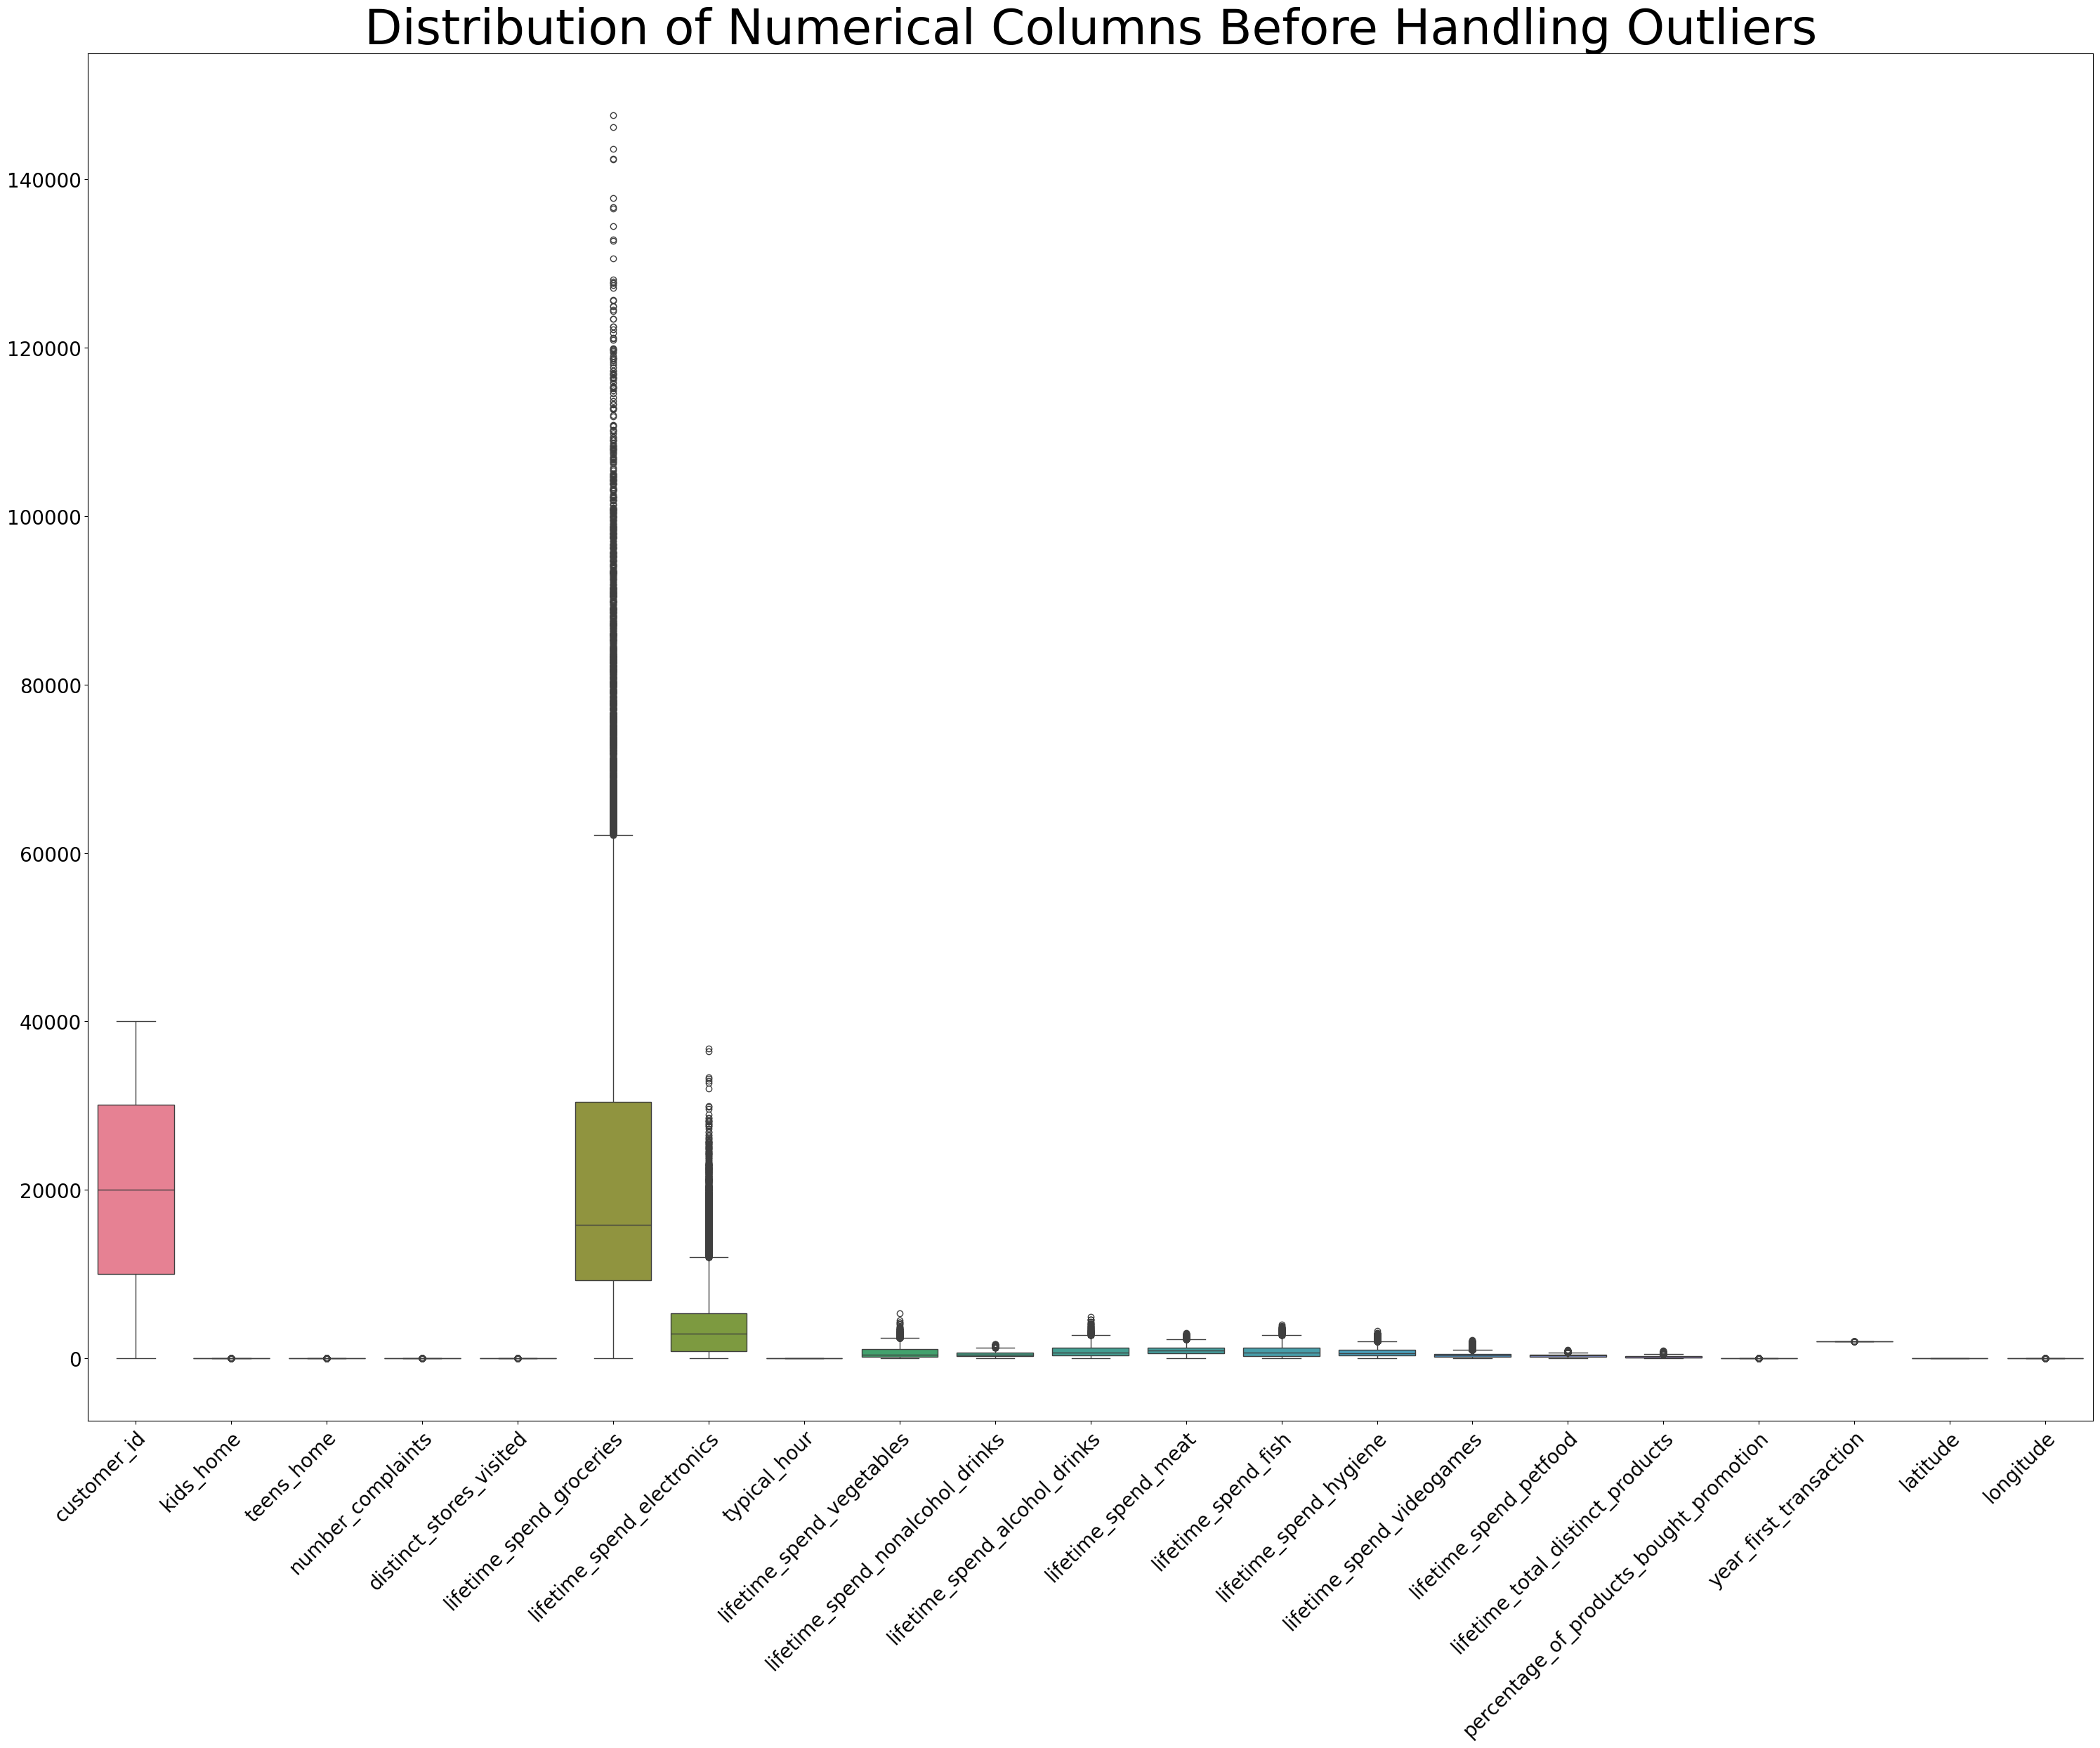

In [236]:
#Creating box plots before handling outliers to visualize the outliers
plt.figure(figsize=(30, 25))
sns.boxplot(data=customer_info[numerical_columns])
plt.xticks(rotation=45, fontsize =20, ha = "right", rotation_mode = "anchor")
plt.yticks(fontsize = 20)
plt.title("Distribution of Numerical Columns Before Handling Outliers", fontsize = 50)
plt.tight_layout()
plt.show()

In [216]:
# Handling outliers
# I decided to to use the IQR method as it is more robust when dealing with outliers.
# Creating a function to handle outliers by replacing them with the IQR
def handle_outliers(customer_info, columns):
    customer_info = customer_info.copy()
    for column in columns:
        Q1 = customer_info[column].quantile(0.25)
        Q3 = customer_info[column].quantile(.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        customer_info[column] = np.where(customer_info[column] < lower_bound, lower_bound, customer_info[column])
        customer_info[column] = np.where(customer_info[column] > upper_bound, upper_bound, customer_info[column])
    
    return customer_info

customer_info_clean = handle_outliers(customer_info, numerical_columns)

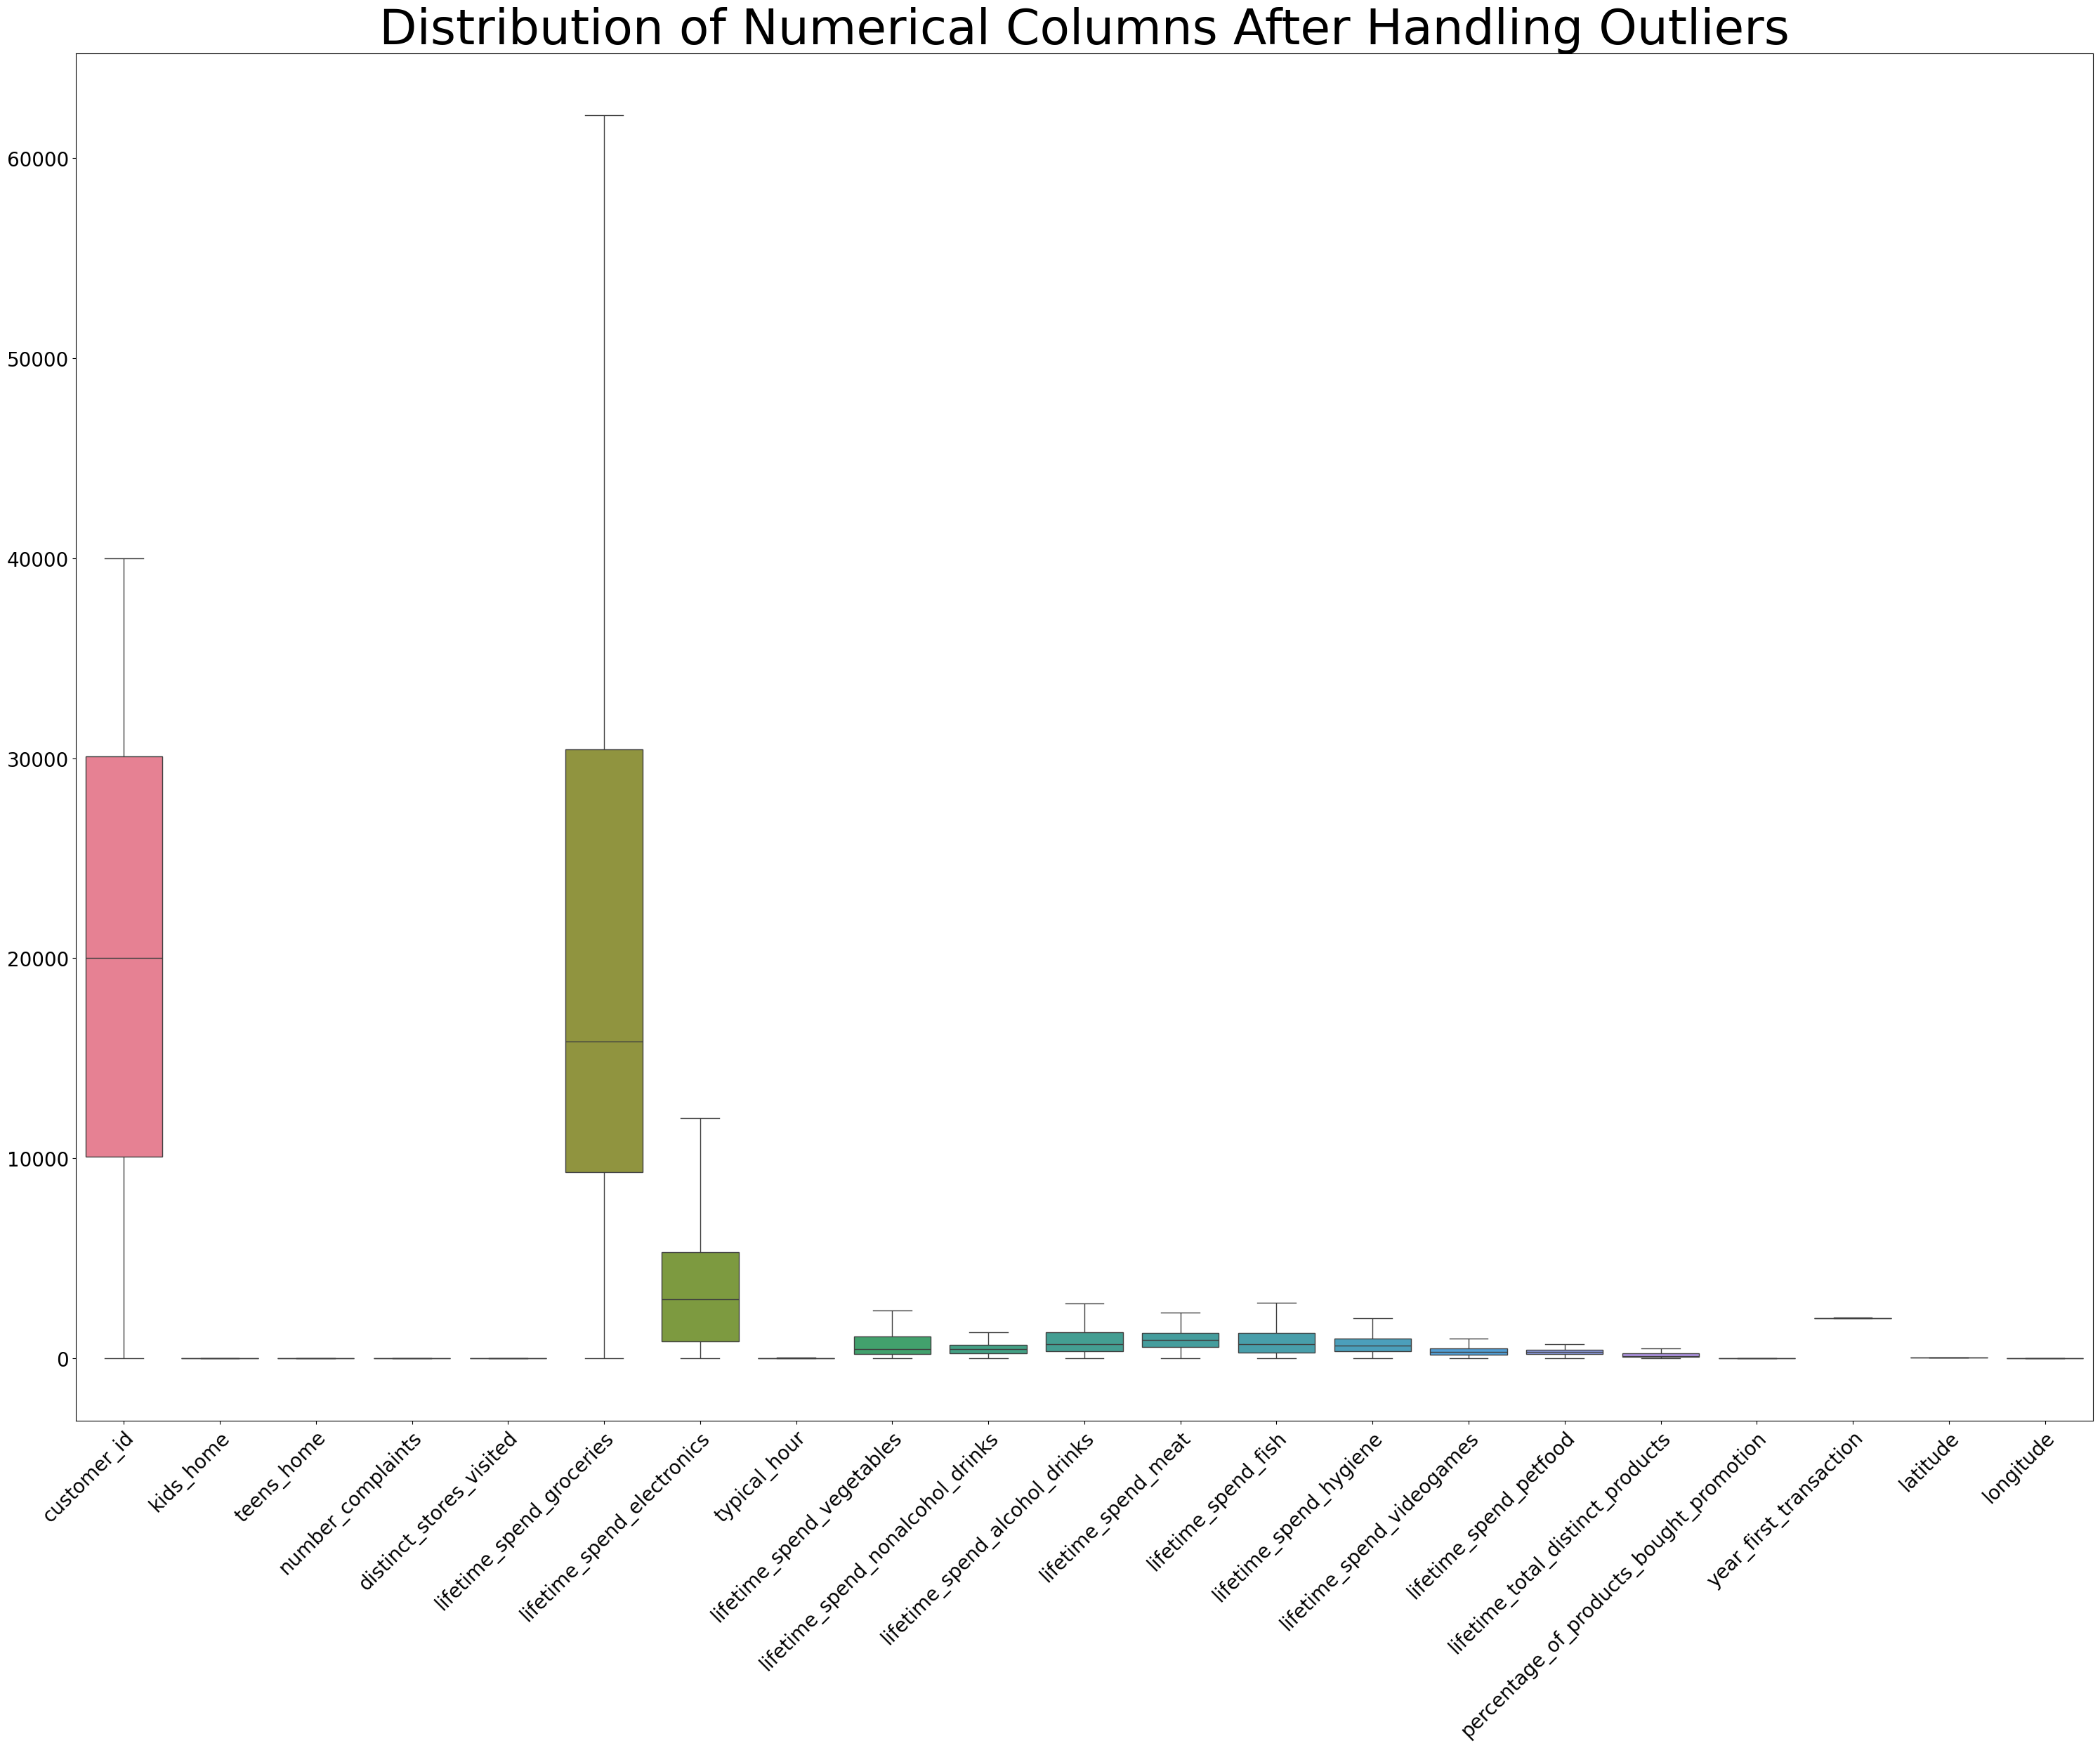

In [235]:
# Creating box plots after handling outliers to compare with the previous plots and check how the distribution changed
plt.figure(figsize=(30, 25))
sns.boxplot(data=customer_info_clean[numerical_columns])
plt.xticks(rotation=45, fontsize =20, ha = "right", rotation_mode = "anchor")
plt.yticks(fontsize = 20)
plt.title("Distribution of Numerical Columns After Handling Outliers", fontsize = 50)
plt.tight_layout()
plt.show()

In [ ]:
# Change data types for selected columns
customer_info_clean = customer_info_clean.astype({
    "customer_id": "int64",
    "age": "int64",
    "kids_home": "int64",
    "teens_home": "int64",
    "number_complaints": "int64",
    "distinct_stores_visited": "int64",
})

# Verify the changes
print("Updated data types:")
print(customer_info_clean.dtypes)

Updated data types:
customer_id                                         int64
customer_name                                      object
customer_gender                                    object
customer_birthdate                         datetime64[ns]
age                                                 int64
kids_home                                           int64
teens_home                                          int64
number_complaints                                   int64
distinct_stores_visited                             int64
lifetime_spend_groceries                          float64
lifetime_spend_electronics                        float64
typical_hour                                      float64
lifetime_spend_vegetables                         float64
lifetime_spend_nonalcohol_drinks                  float64
lifetime_spend_alcohol_drinks                     float64
lifetime_spend_meat                               float64
lifetime_spend_fish                               fl

In [220]:
customer_info_clean

,customer_id,customer_name,customer_gender,customer_birthdate,age,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,latitude,longitude,has_loyalty_card
0,29930,April Clark,female,1972-01-15 14:27:00,53,2,2,1,4,7789.0,...,1894.0,457.0,412.0,428.0,386.0,0.158741,2018.0,38.721807,-9.125534,False
1,6813,Paul Ketchum,male,1944-07-31 10:53:00,80,0,1,0,4,8653.0,...,346.0,394.0,75.0,226.0,73.0,1.112700,2013.0,38.734668,-9.163533,True
2,39451,Mary Downing,female,1989-11-13 14:11:00,35,2,2,0,7,15605.0,...,1971.0,920.0,335.0,192.0,319.0,0.101598,2011.0,38.787126,-9.147077,False
3,21557,Manuel Kueny,male,1976-08-09 06:23:00,48,0,0,1,1,13440.0,...,785.0,139.0,679.0,270.0,221.0,0.259943,2009.0,38.741816,-9.159700,False
4,16415,Curtis Tharp,male,1966-07-11 08:12:00,58,1,1,1,5,49250.0,...,1492.0,1046.0,112.0,144.0,244.0,0.317822,2012.0,38.785921,-9.149221,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34054,27689,Charlotte Banks,female,1967-03-20 13:07:00,58,1,2,0,3,38853.0,...,1135.0,1006.0,524.0,527.0,329.0,0.205564,2010.0,38.742335,-9.178790,True
34055,37071,Mary Diaz,female,1999-01-20 18:47:00,26,1,1,0,2,62126.0,...,1687.0,1048.0,379.0,258.0,163.0,0.162331,2018.0,38.750813,-9.103808,False
34056,27422,John Gross,male,1984-08-01 19:50:00,40,1,1,0,3,16084.0,...,568.0,949.0,263.0,319.0,379.0,0.614179,2019.0,38.745020,-9.169168,True
34057,39540,Kathleen Harper,female,2000-09-16 07:22:00,24,1,0,1,2,14631.0,...,1472.0,368.0,804.0,110.0,228.0,0.535617,2018.0,38.767834,-9.172368,False


DATA VISUALIZATION STARTS HERE

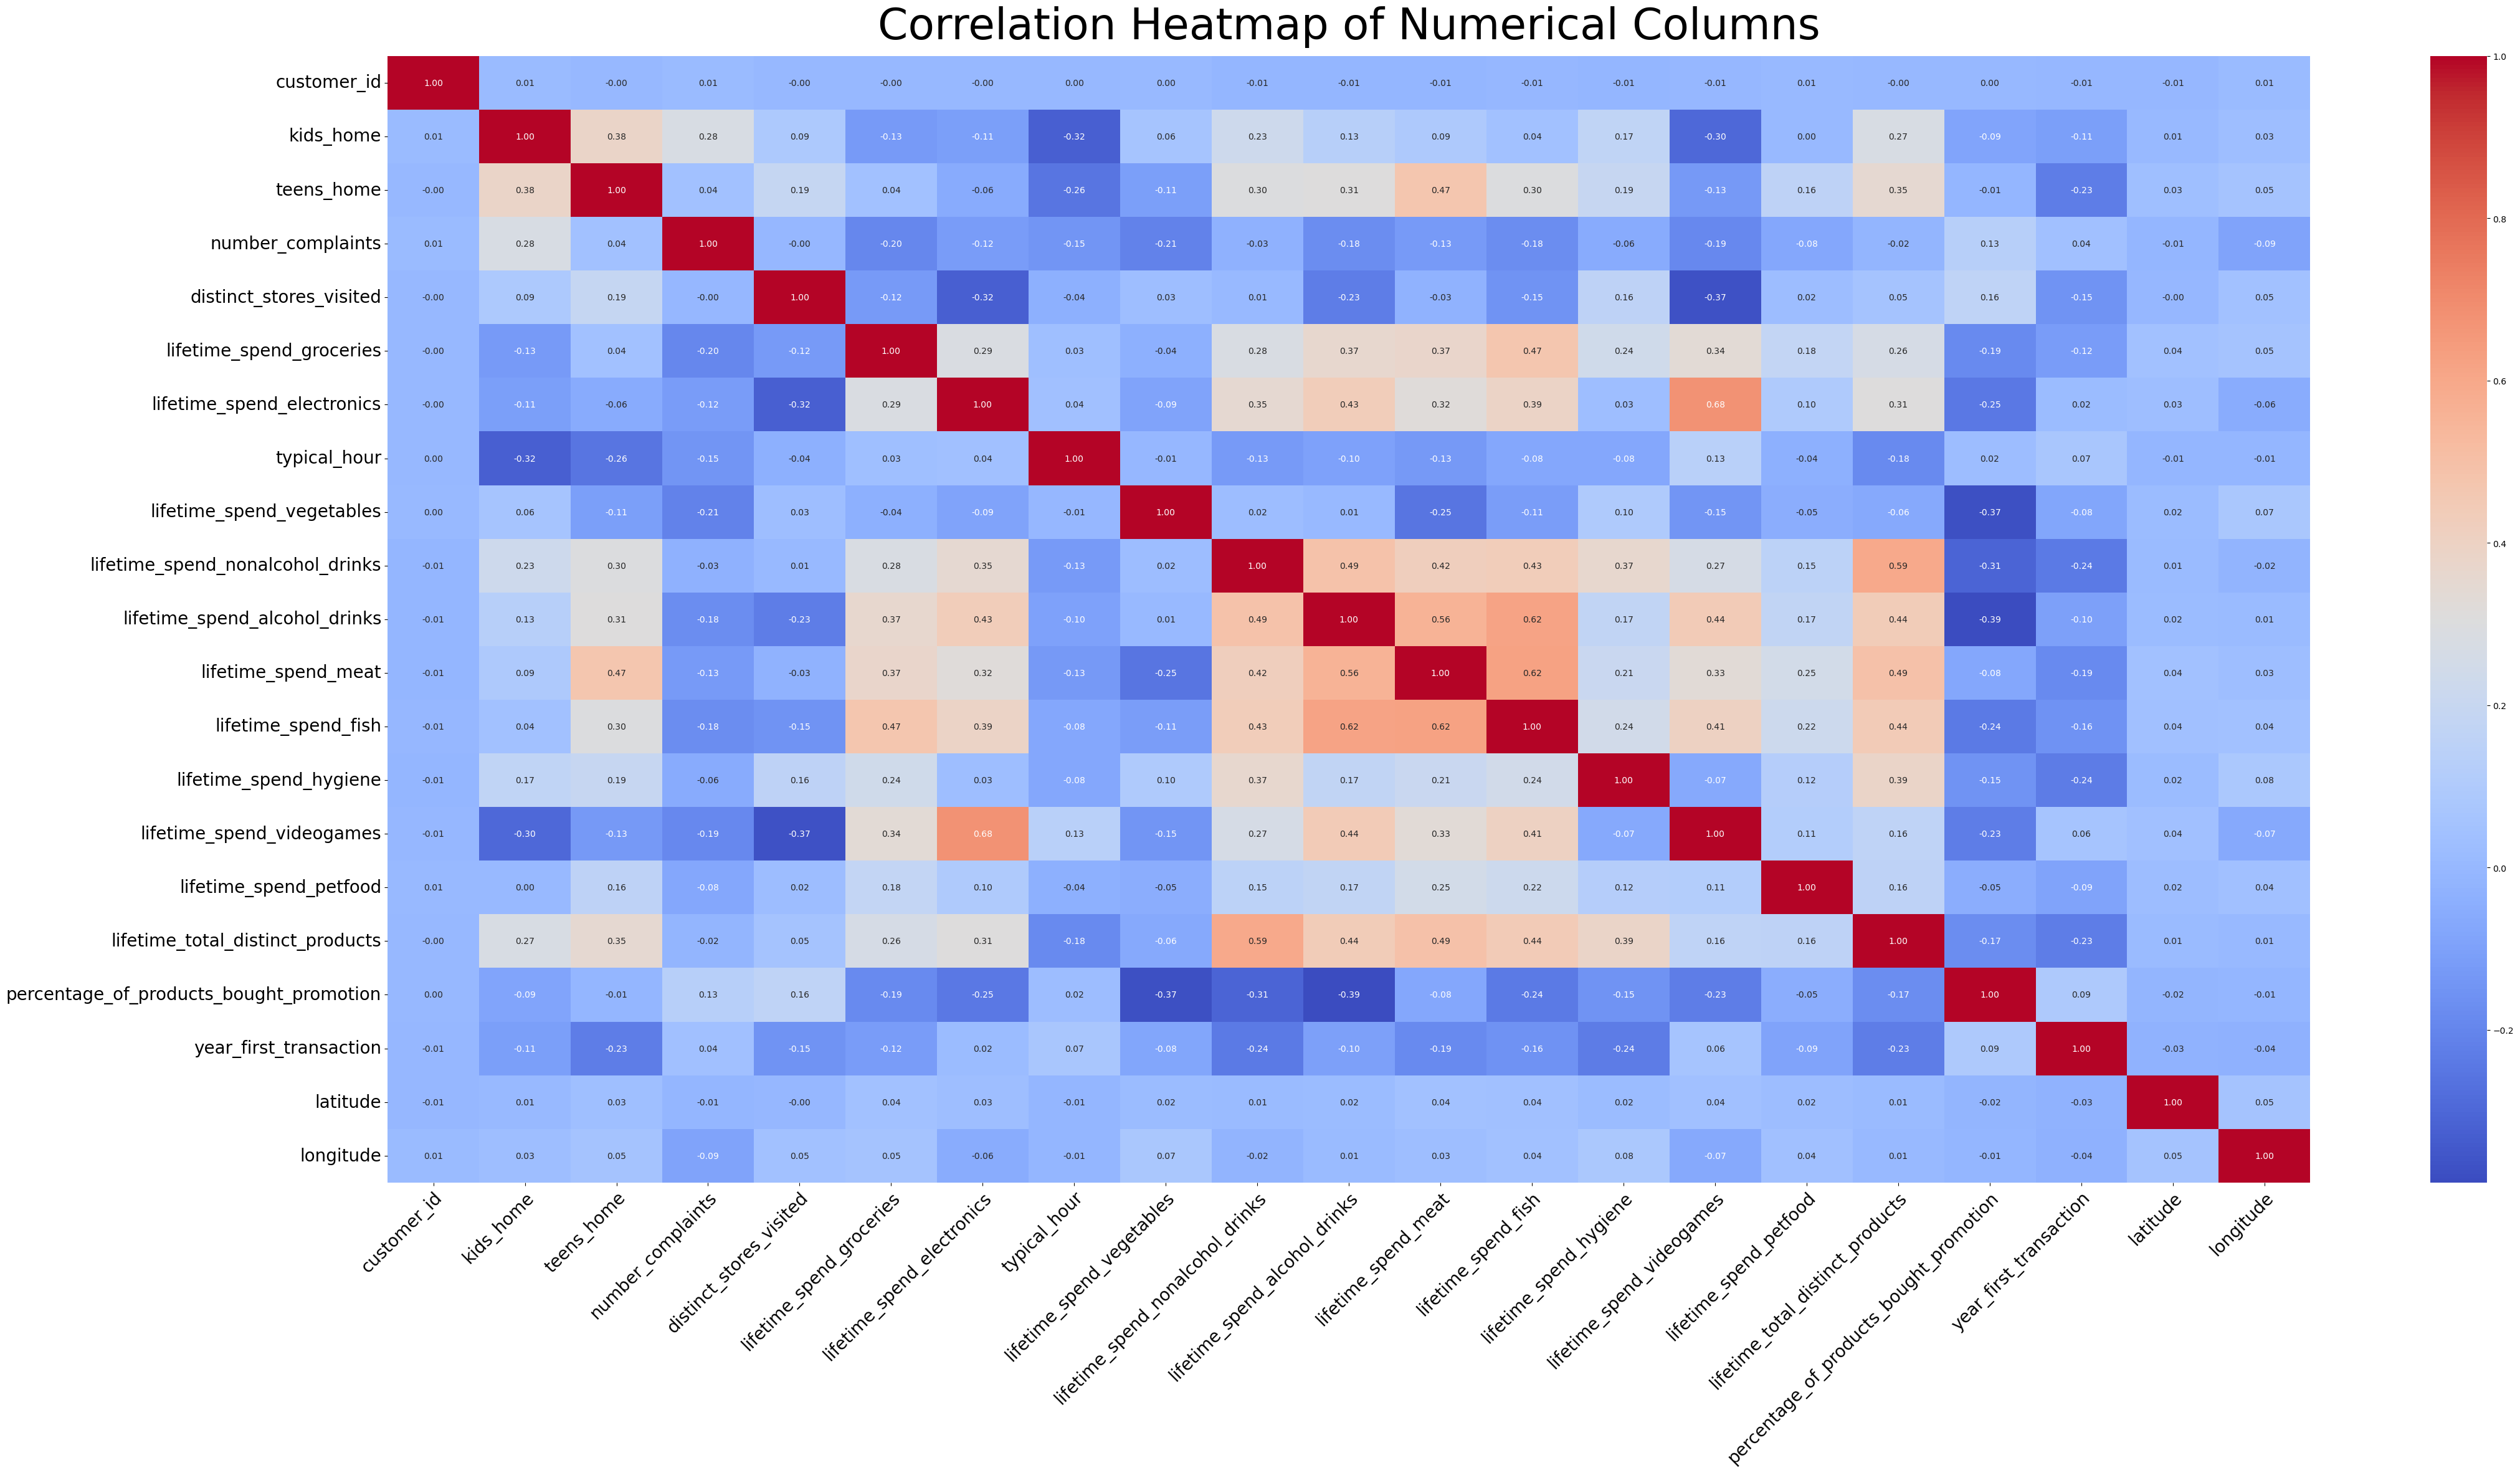

In [ ]:
# Checking the correlation between numerical columns by plotting a correlation heatmap
plt.figure(figsize=(45, 25))

# Create heatmap with adjusted label parameters
sns.heatmap(customer_info_clean[numerical_columns].corr(), 
            annot=True, 
            fmt= ".2f", 
            cmap= "coolwarm", 
            cbar=True)

# Customize title
plt.title("Correlation Heatmap of Numerical Columns", fontsize=50, pad=20)

# Adjust x and y labels with better alignment
plt.xticks(rotation=45, fontsize=20, ha= "right", rotation_mode= "anchor")
plt.yticks(fontsize=20, va= "center")

# Adjust layout to prevent label cutoff
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

/var/folders/28/pbfvjhc55zl308_2rlcfxg800000gn/T/ipykernel_34830/3568465877.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=customer_info_clean, x='age_group', palette='viridis')


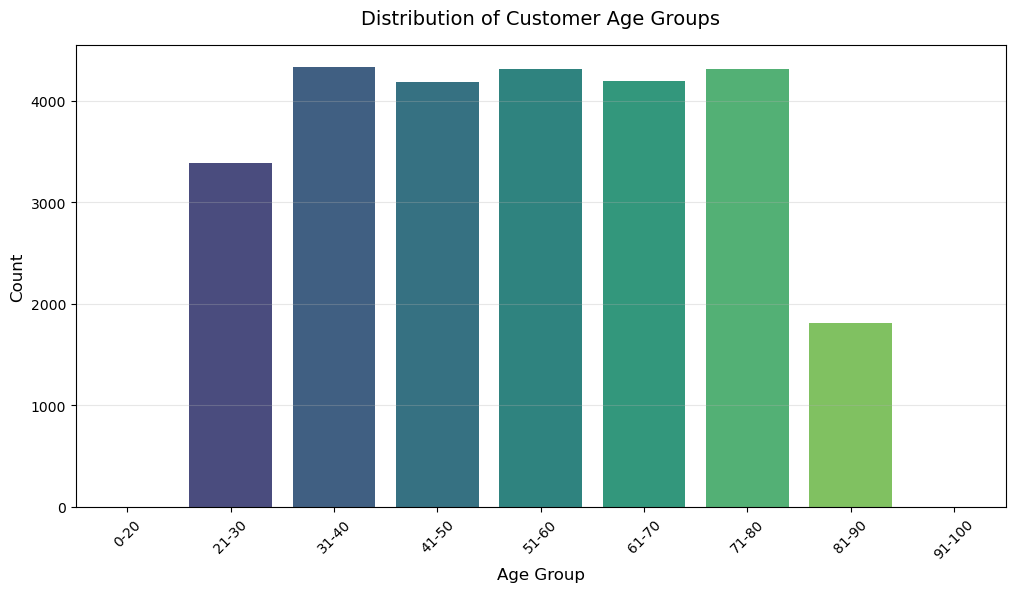

In [ ]:
# Create age groups
bins = [0, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labels = ["0-20", "21-30", "31-40", "41-50", "51-60", "61-70", "71-80", "81-90", "91-100"]
customer_info_clean['age_group'] = pd.cut(customer_info_clean['age'], bins=bins, labels=labels)

# Create a bar plot of age groups
plt.figure(figsize=(12, 6))
sns.countplot(data=customer_info_clean, x= "age_group", palette= "viridis")

# Customize the plot
plt.title("Distribution of Customer Age Groups", fontsize=14, pad=15)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)

# Add grid for better readability
plt.grid(True, alpha=0.3, axis="y")

# Show the plot
plt.show()

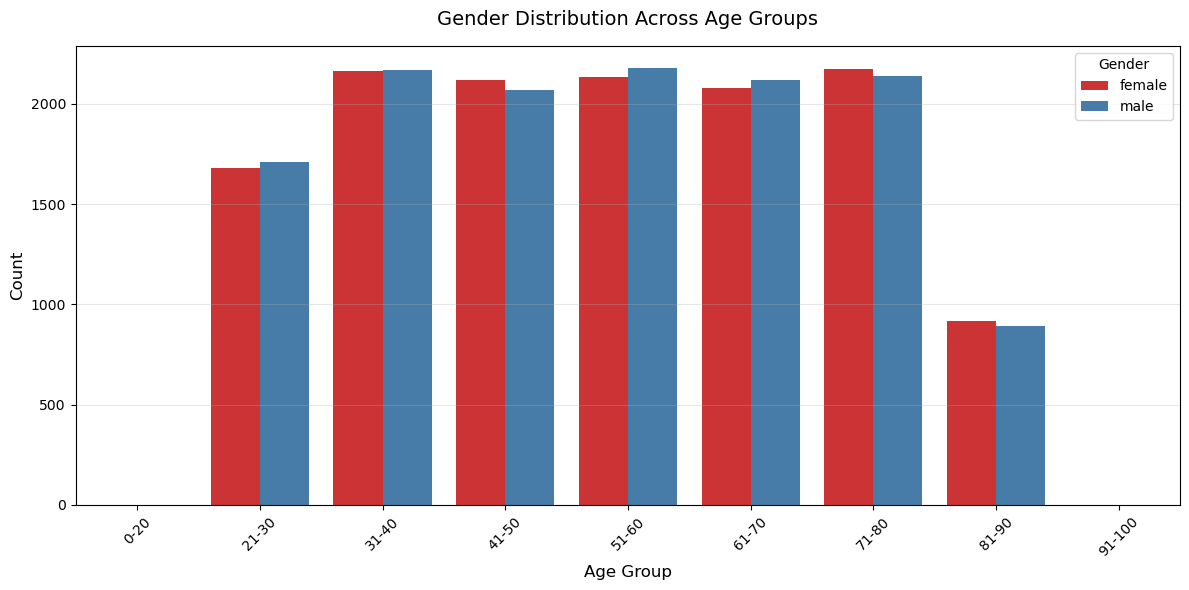

In [ ]:
# Create a grouped bar chart for gender distribution by age group
plt.figure(figsize=(12, 6))
sns.countplot(data=customer_info_clean, 
              x= "age_group", 
              hue= "customer_gender",
              palette= "Set1")

# Customize the plot
plt.title("Gender Distribution Across Age Groups", fontsize=14, pad=15)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title= "Gender")

# Add grid for better readability
plt.grid(True, alpha=0.3, axis= "y")

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

In [229]:
customer_basket

,invoice_id,list_of_goods,customer_id
0,5062209,"['megaman zero 3', 'energy bar', 'pokemon viol...",4925
1,4272512,"['black beer', 'bramble', 'laptop', 'pokemon v...",19046
2,7121052,"['soup', 'shallot', 'cake', 'fresh bread', 'cr...",10318
3,5847748,"['soup', 'cooking oil', 'cereals', 'oil', 'dog...",27283
4,6336114,"['eggplant', 'mint green tea', 'oil', 'bacon',...",16072
...,...,...,...
99995,5389466,"['frozen smoothie', 'avocado', 'dog food', 'ch...",26170
99996,10387390,"['cake', 'antioxydant juice', 'honey', 'toothp...",19691
99997,7103407,"['candy bars', 'spaghetti', 'oil', 'final fant...",1720
99998,4093515,"['shallot', 'cereals', 'oil', 'deodorant', 'me...",24989


/var/folders/28/pbfvjhc55zl308_2rlcfxg800000gn/T/ipykernel_34830/196137197.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=item_counts.values, y=item_counts.index, palette='viridis')


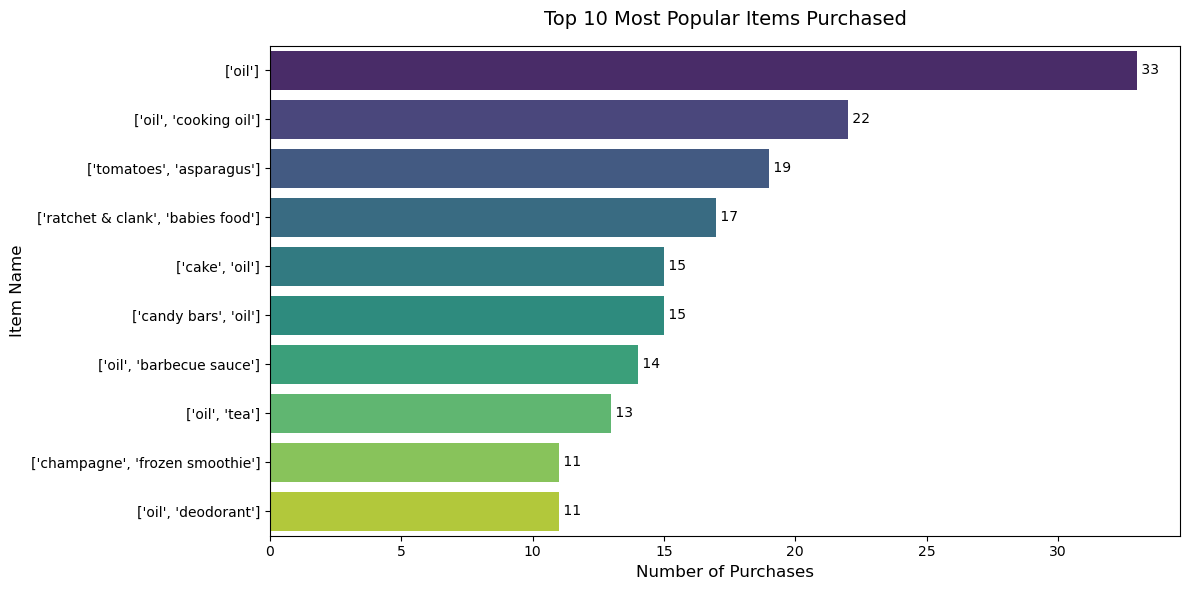

In [ ]:
# Group by item and count occurrences
item_counts = customer_basket["list_of_goods"].value_counts().head(10)  # Get top 10 items

# Create a figure with larger size
plt.figure(figsize=(12, 6))

# Create bar plot
sns.barplot(x=item_counts.values, y=item_counts.index, palette= "viridis")

# Customize the plot
plt.title("Top 10 Most Popular Items Purchased", fontsize=14, pad=15)
plt.xlabel("Number of Purchases", fontsize=12)
plt.ylabel("Item Name", fontsize=12)

# Add value labels on the bars
for i, v in enumerate(item_counts.values):
    plt.text(v, i, f' {v:,}', va= "center", fontsize=10)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

/var/folders/28/pbfvjhc55zl308_2rlcfxg800000gn/T/ipykernel_34830/1352051104.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers.index, y=top_customers.values, palette='viridis')


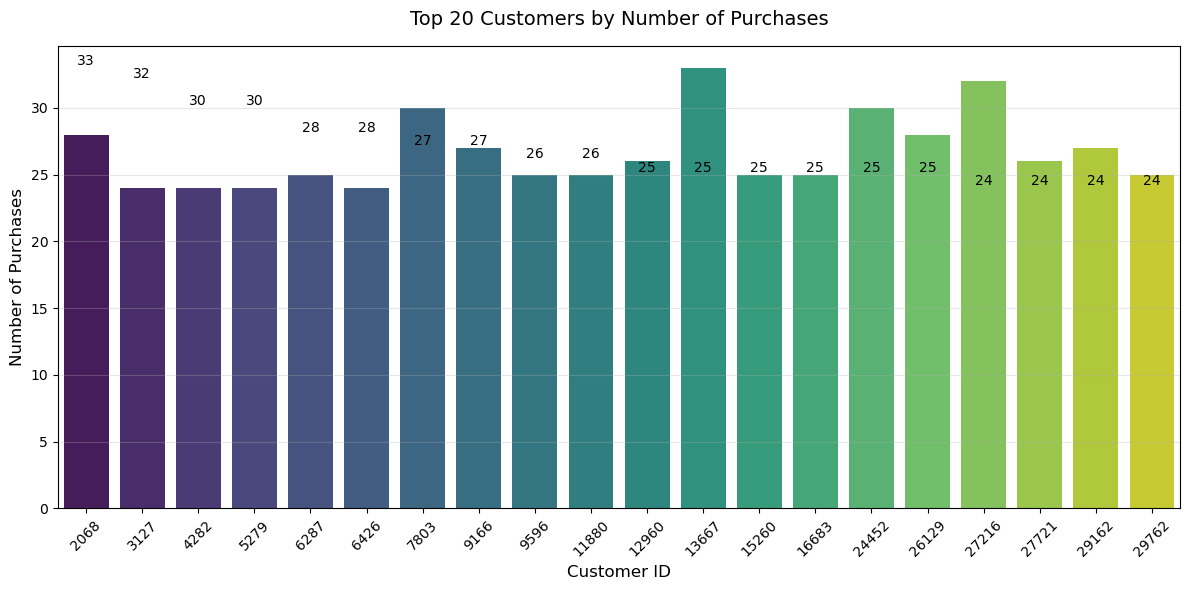

In [240]:
# Create a new cell to analyze purchases by customer
plt.figure(figsize=(12, 6))

# Group by customer_id and count their purchases
customer_purchases = customer_basket.groupby('customer_id')['list_of_goods'].count().sort_values(ascending=False)

# Plot top 20 customers for better visibility
top_customers = customer_purchases.head(20)

# Create bar plot
sns.barplot(x=top_customers.index, y=top_customers.values, palette='viridis')

# Customize the plot
plt.title('Top 20 Customers by Number of Purchases', fontsize=14, pad=15)
plt.xlabel('Customer ID', fontsize=12)
plt.ylabel('Number of Purchases', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add value labels on the bars
for i, v in enumerate(top_customers.values):
    plt.text(i, v, f'{int(v)}', ha='center', va='bottom')

# Add grid for better readability
plt.grid(True, alpha=0.3, axis='y')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

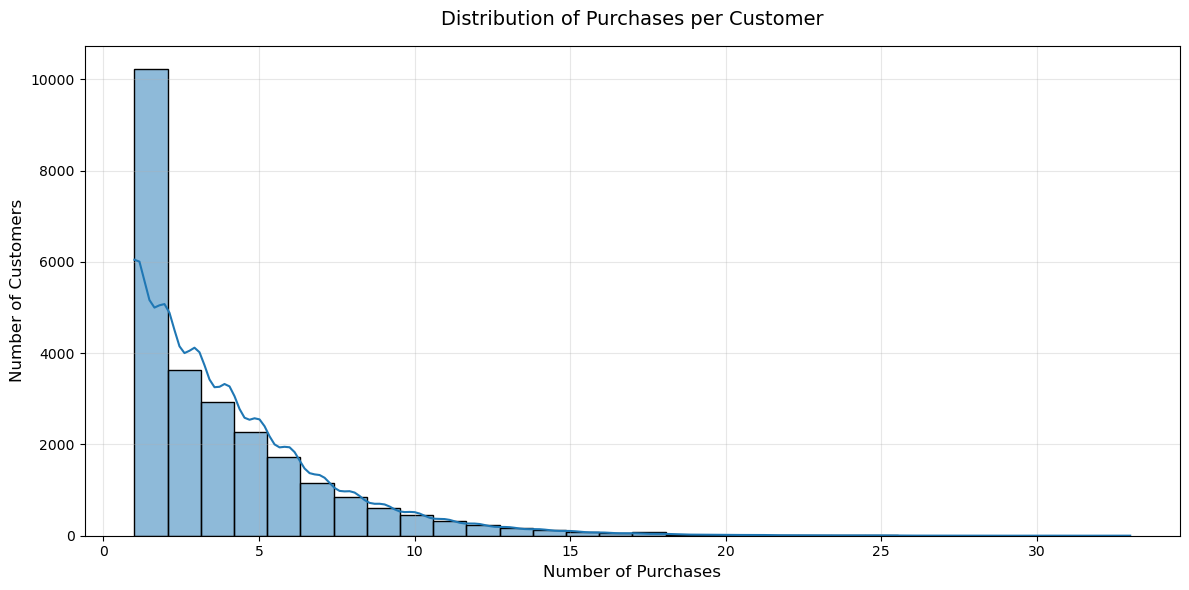

In [241]:
# Create a histogram of purchases per customer
plt.figure(figsize=(12, 6))

# Plot histogram
sns.histplot(data=customer_purchases, bins=30, kde=True)

# Customize the plot
plt.title('Distribution of Purchases per Customer', fontsize=14, pad=15)
plt.xlabel('Number of Purchases', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()